# Advanced Customer Segmentation Analysis

## Project Overview

This project focuses on advanced customer segmentation analysis using unsupervised machine learning techniques. The objective was to identify meaningful customer groups based on customer annual income and spending behavior.
The analysis applies multiple clustering algorithms, evaluates their performance using statistical metrics, and uses Principal Component Analysis (PCA) for dimensionality reduction and visualization.
The project demonstrates practical applications of machine learning in customer analytics, market segmentation, and business intelligence.

## Objectives
- Load and preprocess customer data for machine learning analysis.
- Standardize numerical features to improve clustering accuracy.
- Implement and compare multiple clustering algorithms:
 - K-Means Clustering
 - DBSCAN
 - Agglomerative Clustering
 - Gaussian Mixture Models (GMM)
- Evaluate clustering performance using:
 - Silhouette Score
 - Davies-Bouldin Index
 - Calinski-Harabasz Score
- Visualize clustering results across algorithms.
- Perform PCA for dimensionality reduction and feature interpretation.
- Identify the optimal number of clusters.
- Generate actionable business insights from customer segments.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [6]:
df = pd.read_csv("../data/customer_data.csv")
X_raw = df[["AnnualIncome", "SpendingScore"]]

# Scale features — DBSCAN and Agglomerative are distance-sensitive
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print("Data loaded successfully!")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Data loaded successfully!
Shape: 40 rows, 3 columns


,CustomerID,AnnualIncome,SpendingScore
0,1,15,39
1,2,15,81
2,3,16,6
3,4,16,77
4,5,17,40


In [7]:
# K-Means (baseline)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X)

# DBSCAN — density-based, discovers clusters of arbitrary shape
# eps controls neighborhood radius; min_samples = minimum cluster size
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)
# Note: label -1 = noise points (outliers)

# Agglomerative (Hierarchical) Clustering
agglo = AgglomerativeClustering(n_clusters=5, linkage="ward")
labels_agglo = agglo.fit_predict(X)

# Gaussian Mixture Model — soft probabilistic assignments
gmm = GaussianMixture(n_components=5, random_state=42)
labels_gmm = gmm.fit_predict(X)

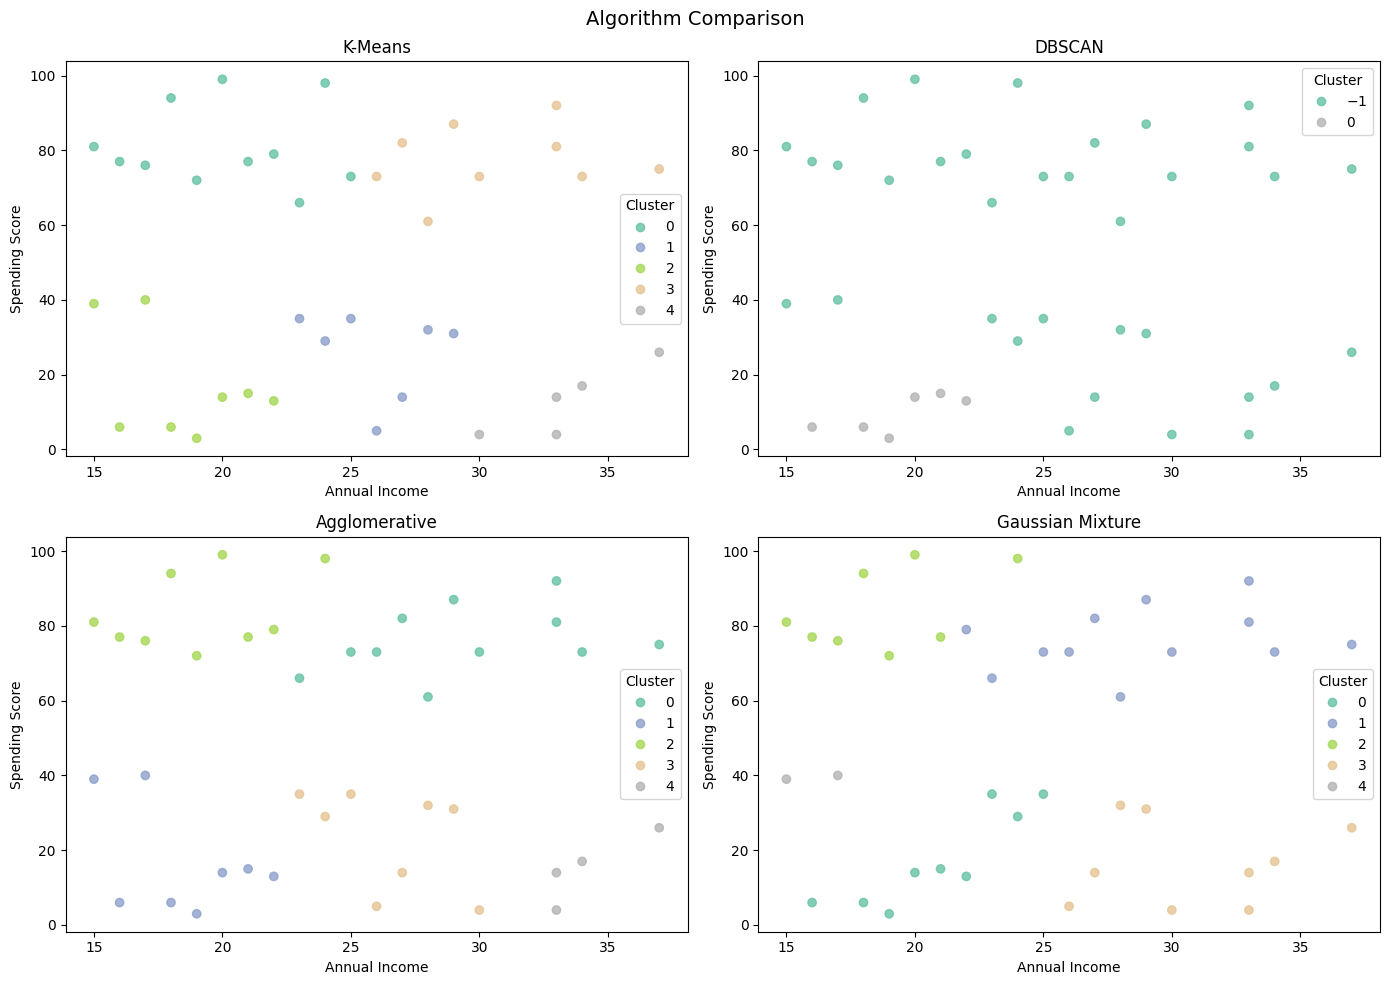

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Algorithm Comparison", fontsize=14)

datasets = [
    (labels_kmeans, "K-Means"),
    (labels_dbscan, "DBSCAN"),
    (labels_agglo,  "Agglomerative"),
    (labels_gmm,    "Gaussian Mixture"),
]

for ax, (labels, title) in zip(axes.flatten(), datasets):
    scatter = ax.scatter(
        X_raw["AnnualIncome"], X_raw["SpendingScore"],
        c=labels, cmap="Set2", alpha=0.8
    )
    ax.set_title(title)
    ax.set_xlabel("Annual Income")
    ax.set_ylabel("Spending Score")
    ax.legend(*scatter.legend_elements(), title="Cluster")

plt.tight_layout()
plt.savefig("../visuals/algorithm_comparison.png", dpi=150)
plt.show()

In [5]:
for eps in [0.3, 0.5, 0.7, 1.0]:
    db = DBSCAN(eps=eps, min_samples=5)
    lbls = db.fit_predict(X)
    n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
    n_noise    = list(lbls).count(-1)
    print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points")

eps=0.3: 0 clusters, 40 noise points
eps=0.5: 1 clusters, 34 noise points
eps=0.7: 2 clusters, 4 noise points
eps=1.0: 1 clusters, 1 noise points


In [8]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.read_csv("../data/customer_data.csv")
X_raw = df[["AnnualIncome", "SpendingScore"]]
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)

    results.append({"K": k, "Silhouette": round(sil, 4),
                    "Davies-Bouldin": round(dbi, 4),
                    "Calinski-Harabasz": round(ch, 2)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
results_df.to_csv("../data/cluster_evaluation.csv", index=False)

 K  Silhouette  Davies-Bouldin  Calinski-Harabasz
 2      0.4138          1.0155              29.64
 3      0.4092          0.7784              33.58
 4      0.4558          0.6855              48.99
 5      0.4479          0.7118              48.38
 6      0.4312          0.7119              52.93
 7      0.4503          0.6342              54.06
 8      0.4313          0.7104              55.33
 9      0.4277          0.7112              56.55
10      0.4170          0.6780              54.73


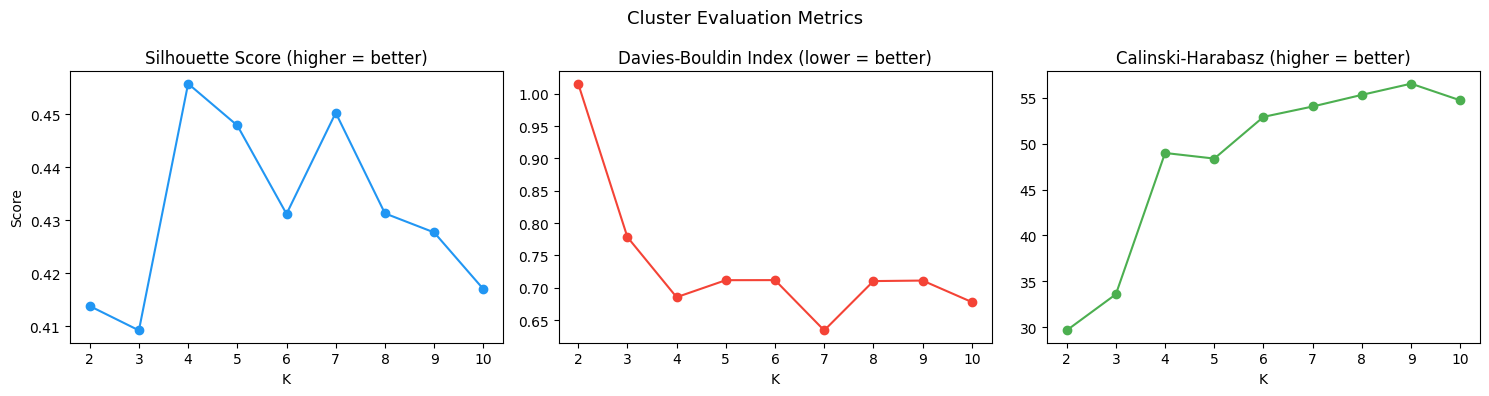

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Cluster Evaluation Metrics", fontsize=13)

axes[0].plot(results_df["K"], results_df["Silhouette"], marker="o", color="#2196F3")
axes[0].set_title("Silhouette Score (higher = better)")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Score")

axes[1].plot(results_df["K"], results_df["Davies-Bouldin"], marker="o", color="#F44336")
axes[1].set_title("Davies-Bouldin Index (lower = better)")
axes[1].set_xlabel("K")

axes[2].plot(results_df["K"], results_df["Calinski-Harabasz"], marker="o", color="#4CAF50")
axes[2].set_title("Calinski-Harabasz (higher = better)")
axes[2].set_xlabel("K")

plt.tight_layout()
plt.savefig("../visuals/cluster_evaluation.png", dpi=150)
plt.show()

In [10]:
# Compare K-Means, Agglomerative, and GMM at k=5
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

models = {
    "K-Means":        KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X),
    "Agglomerative":  AgglomerativeClustering(n_clusters=5).fit_predict(X),
    "GMM":            GaussianMixture(n_components=5, random_state=42).fit_predict(X),
}

print(f"{'Algorithm':<20} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-H':>12}")
print("-" * 62)
for name, labels in models.items():
    s  = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    print(f"{name:<20} {s:>12.4f} {db:>16.4f} {ch:>12.2f}")

Algorithm              Silhouette   Davies-Bouldin   Calinski-H
--------------------------------------------------------------
K-Means                    0.4479           0.7118        48.38
Agglomerative              0.4290           0.7233        44.12
GMM                        0.3875           0.7012        35.73


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("../data/customer_data.csv")
X_raw = df[["AnnualIncome", "SpendingScore"]]

# Step 1: Always scale before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Step 2: Fit PCA
pca = PCA()
pca.fit(X_scaled)

# Step 3: Explained variance — how much info each component captures
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Explained variance per component:")
for i, (e, c) in enumerate(zip(explained, cumulative), 1):
    print(f"  PC{i}: {e*100:.1f}%  (cumulative: {c*100:.1f}%)")

Explained variance per component:
  PC1: 51.9%  (cumulative: 51.9%)
  PC2: 48.1%  (cumulative: 100.0%)


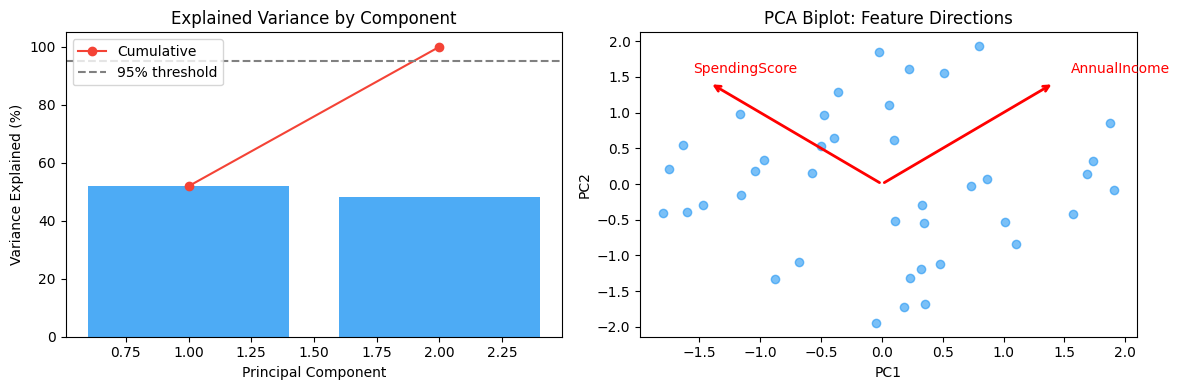

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
axes[0].bar(range(1, len(explained)+1), explained*100, color="#2196F3", alpha=0.8)
axes[0].plot(range(1, len(explained)+1), cumulative*100,
             marker="o", color="#F44336", label="Cumulative")
axes[0].axhline(y=95, color="gray", linestyle="--", label="95% threshold")
axes[0].set_title("Explained Variance by Component")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].legend()

# Biplot: show original feature directions in PCA space
X_pca = pca.transform(X_scaled)
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color="#2196F3")
features = ["AnnualIncome", "SpendingScore"]
for i, feat in enumerate(features):
    axes[1].annotate(
        "", xy=(pca.components_[0, i]*2, pca.components_[1, i]*2),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color="red", lw=2)
    )
    axes[1].text(pca.components_[0, i]*2.2, pca.components_[1, i]*2.2,
                 feat, fontsize=10, color="red")
axes[1].set_title("PCA Biplot: Feature Directions")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.savefig("../visuals/pca_analysis.png", dpi=150)
plt.show()

Components needed for 95% variance: 2


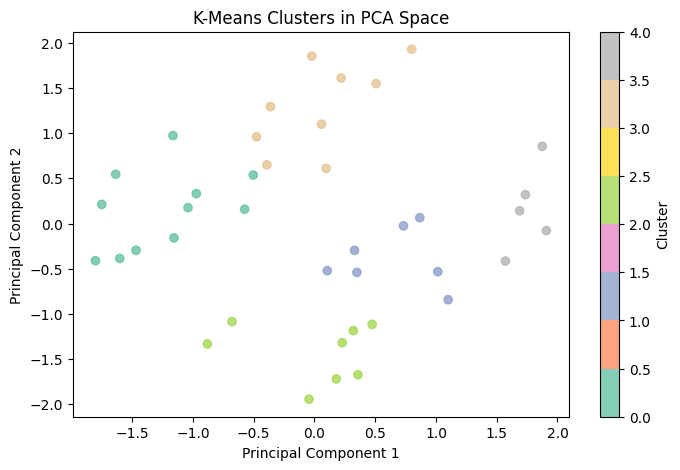

In [13]:
# Choose number of components that explain 95%+ of variance
n_components = np.argmax(cumulative >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components}")

pca_reduced = PCA(n_components=n_components)
X_pca = pca_reduced.fit_transform(X_scaled)

# Cluster in PCA space
kmeans_pca = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster_PCA"] = kmeans_pca.fit_predict(X_pca)

# Visualize clusters in PCA space
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            c=df["Cluster_PCA"], cmap="Set2", alpha=0.8)
plt.title("K-Means Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")
plt.savefig("../visuals/pca_clusters.png", dpi=150)
plt.show()

In [14]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))],
    index=["AnnualIncome", "SpendingScore"]
)
print("PCA Loadings (feature contributions per component):")
print(loadings.round(4))

PCA Loadings (feature contributions per component):
                  PC1     PC2
AnnualIncome   0.7071  0.7071
SpendingScore -0.7071  0.7071


# Analysis Insights

## Customer Segmentation Insights

The analysis grouped customers based on their annual income and spending behavior. Different customer groups showed different buying patterns, which can help businesses better understand their customers.

The results also showed that customers with similar incomes may spend money very differently. This means businesses should not rely only on income when making marketing decisions.

---

# Clustering Algorithm Insights

## K-Means Clustering

K-Means created clear and balanced customer groups.

### Key Findings
- Customers were grouped clearly.
- The clusters were easy to understand.
- The algorithm performed well overall.

K-Means was one of the best-performing clustering methods in this project.

---

## DBSCAN Insights

DBSCAN identified dense customer groups and also detected unusual customers (outliers).

### Key Findings
- Some customers were identified as noise points.
- The results changed depending on the `eps` value.
- Useful for finding unusual customer behavior.

DBSCAN is useful for detecting outliers and abnormal spending patterns.

---

## Agglomerative Clustering Insights

Agglomerative clustering grouped customers based on similarities.

### Key Findings
- Similar customers were grouped together.
- The clustering structure was easy to follow.
- Results were similar to K-Means.

This method worked well for finding natural customer relationships.

---

## Gaussian Mixture Model (GMM) Insights

GMM created more flexible clusters compared to K-Means.

### Key Findings
- Customers could partially belong to different groups.
- Cluster boundaries were softer and more flexible.
- Worked well for overlapping customer patterns.

GMM handled complex customer behavior effectively.

---

# Cluster Evaluation Insights

Three metrics were used to evaluate clustering quality.

---

## Silhouette Score

- Higher values mean better clustering.
- Helped identify the best number of clusters.

---

## Davies-Bouldin Index

- Lower values mean better cluster separation.
- Helped measure cluster similarity.

---

## Calinski-Harabasz Score

- Higher values indicate stronger cluster quality.
- Helped confirm the best clustering structure.

---

# PCA Insights

## Dimensionality Reduction

PCA reduced the complexity of the dataset while keeping most of the important information.

### Key Findings
- Fewer dimensions were needed to represent the data.
- Visualization became easier.
- Important patterns were still preserved.

---

## Feature Contribution Insights

The PCA results showed that both:
- Annual Income
- Spending Score

played important roles in customer segmentation.

Spending Score had a strong influence on cluster formation.

---

# Visualization Insights

The graphs and plots helped compare clustering results and understand customer groups more clearly.

### Key Findings
- Different algorithms created different cluster shapes.
- K-Means and Agglomerative clustering produced similar results.
- DBSCAN highlighted outliers effectively.
- PCA visualizations simplified the cluster structure.

---

# Business Insights

## High-Value Customers

Some customer groups had:
- High income
- High spending behavior

These customers are valuable for:
- Loyalty programs
- Premium products
- Targeted marketing campaigns

---

## Low-Spending Customers

Some groups showed lower spending behavior.

Businesses can target these customers with:
- Promotions
- Discounts
- Personalized offers

---

## Outlier Customers

DBSCAN identified unusual customers with different spending patterns.

These customers may represent:
- Unique customer behavior
- Special market segments
- Potential anomalies

---

# Conclusion

The analysis successfully identified meaningful customer groups using clustering algorithms and PCA.

The project demonstrated how machine learning can help businesses:
- Understand customer behavior
- Improve marketing strategies
- Identify valuable customers
- Support better business decisions